# Pré-processamento e Organização das Imagens

In [ ]:
# Conectando o Google Colab ao Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [ ]:
import os

caminho_principal = '2TIAO\\FASE4-CARDIOIA\\dataset\\2026-Fase4-Imagens' #ajustar caminho das imagens

caminho_train = os.path.join(caminho_principal, 'train')
caminho_test = os.path.join(caminho_principal, 'test')

categorias = [
    'Normal Person ECG Images (284x12=3408)',
    'ECG Images of Myocardial Infarction Patients (240x12=2880)',
    'ECG Images of Patient that have abnormal heartbeat (233x12=2796)',
    'ECG Images of Patient that have History of MI (172x12=2064)'
]

tamanho_imagem = 224

# Função reutilizável para ler as imagens
def carregar_dados(diretorio_base, categorias, tamanho):
    dados = []
    labels = []

    for categoria in categorias:
        caminho_pasta = os.path.join(diretorio_base, categoria)
        class_num = categorias.index(categoria)


        if not os.path.exists(caminho_pasta):
            print(f"Aviso: Pasta não encontrada - {caminho_pasta}")
            continue

        for img_name in os.listdir(caminho_pasta):
            try:
                caminho_img = os.path.join(caminho_pasta, img_name)
                img = cv2.imread(caminho_img, cv2.IMREAD_COLOR)

                if img is not None:
                    img_resized = cv2.resize(img, (tamanho, tamanho))
                    dados.append(img_resized)
                    labels.append(class_num)
            except Exception as e:
                pass # Ignora arquivos corrompidos ou não-imagens

    return np.array(dados), np.array(labels)

In [ ]:
print("Iniciando o carregamento dos dados de TREINO...")
X_train_full, y_train_full = carregar_dados(caminho_train, categorias, tamanho_imagem)

print("Iniciando o carregamento dos dados de TESTE...")
X_test, y_test = carregar_dados(caminho_test, categorias, tamanho_imagem)

print("Normalizando as imagens (escala 0 a 1)...")
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

Iniciando o carregamento dos dados de TREINO...
Iniciando o carregamento dos dados de TESTE...
Normalizando as imagens (escala 0 a 1)...


In [ ]:
# Transformando os labels (0, 1, 2, 3) em matrizes (One-Hot Encoding)
y_train_full = to_categorical(y_train_full, num_classes=4)
y_test = to_categorical(y_test, num_classes=4)

# Separando 20% dos dados de treino para validação
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print("--- Pré-processamento Concluído! ---")
print(f"Total de imagens para TREINAR a IA: {len(X_train)}")
print(f"Total de imagens para VALIDAR durante o treino: {len(X_val)}")
print(f"Total de imagens para TESTAR o protótipo final: {len(X_test)}")

--- Pré-processamento Concluído! ---
Total de imagens para TREINAR a IA: 531
Total de imagens para VALIDAR durante o treino: 133
Total de imagens para TESTAR o protótipo final: 280


# Classificação de Imagens com CNN

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Reverter para números simples (0, 1, 2, 3)
y_train_inteiros = np.argmax(y_train, axis=1)

# Calcula os pesos
pesos = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_inteiros), y=y_train_inteiros)

# Traduzindo os pesos para o Keras
pesos_das_classes = dict(enumerate(pesos))

print("Pesos para o treinamento:", pesos_das_classes)

Pesos para o treinamento: {0: np.float64(1.10625), 1: np.float64(0.9092465753424658), 2: np.float64(0.968978102189781), 3: np.float64(1.037109375)}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Arquitetura
modelo_basico = Sequential([
    # Camadas de extração de características
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Achata as imagens para um vetor unidimensional
    Flatten(),

    # Camadas de decisão
    Dense(128, activation='relu'),
    Dropout(0.5), # Evitando Overfitting
    Dense(4, activation='softmax') # 4 classes
])

# Compilando o modelo
modelo_basico.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Iniciando o treinamento da CNN Simples...")

# Treinamento
history_basico = modelo_basico.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_val, y_val),
    class_weight=pesos_das_classes
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando o treinamento da CNN Simples...
Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 351ms/step - accuracy: 0.2486 - loss: 5.3684 - val_accuracy: 0.1805 - val_loss: 1.3857
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.3126 - loss: 1.3703 - val_accuracy: 0.2105 - val_loss: 1.3542
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4539 - loss: 1.3319 - val_accuracy: 0.4737 - val_loss: 1.3370
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.4821 - loss: 1.2446 - val_accuracy: 0.4887 - val_loss: 1.0600
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.6328 - loss: 0.8942 - val_accuracy: 0.8195 - val_loss: 0.6314
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8249 - loss: 0.5464 - val_accuracy: 0.7895 - val_loss: 0.4949
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8738 - loss: 0.3744 - val_accuracy: 0.8872 - val_loss: 0.3695
Epoch 8/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.93

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step
--- RELATÓRIO DE CLASSIFICAÇÃO FINAL ---
                                                                  precision    recall  f1-score   support

                          Normal Person ECG Images (284x12=3408)       1.00      0.97      0.99        70
      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.99      1.00      0.99        70
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       1.00      1.00      1.00        70
     ECG Images of Patient that have History of MI (172x12=2064)       0.99      1.00      0.99        70

                                                        accuracy                           0.99       280
                                                       macro avg       0.99      0.99      0.99       280
                                                    weighted avg       0.99      0.99      0.99       280



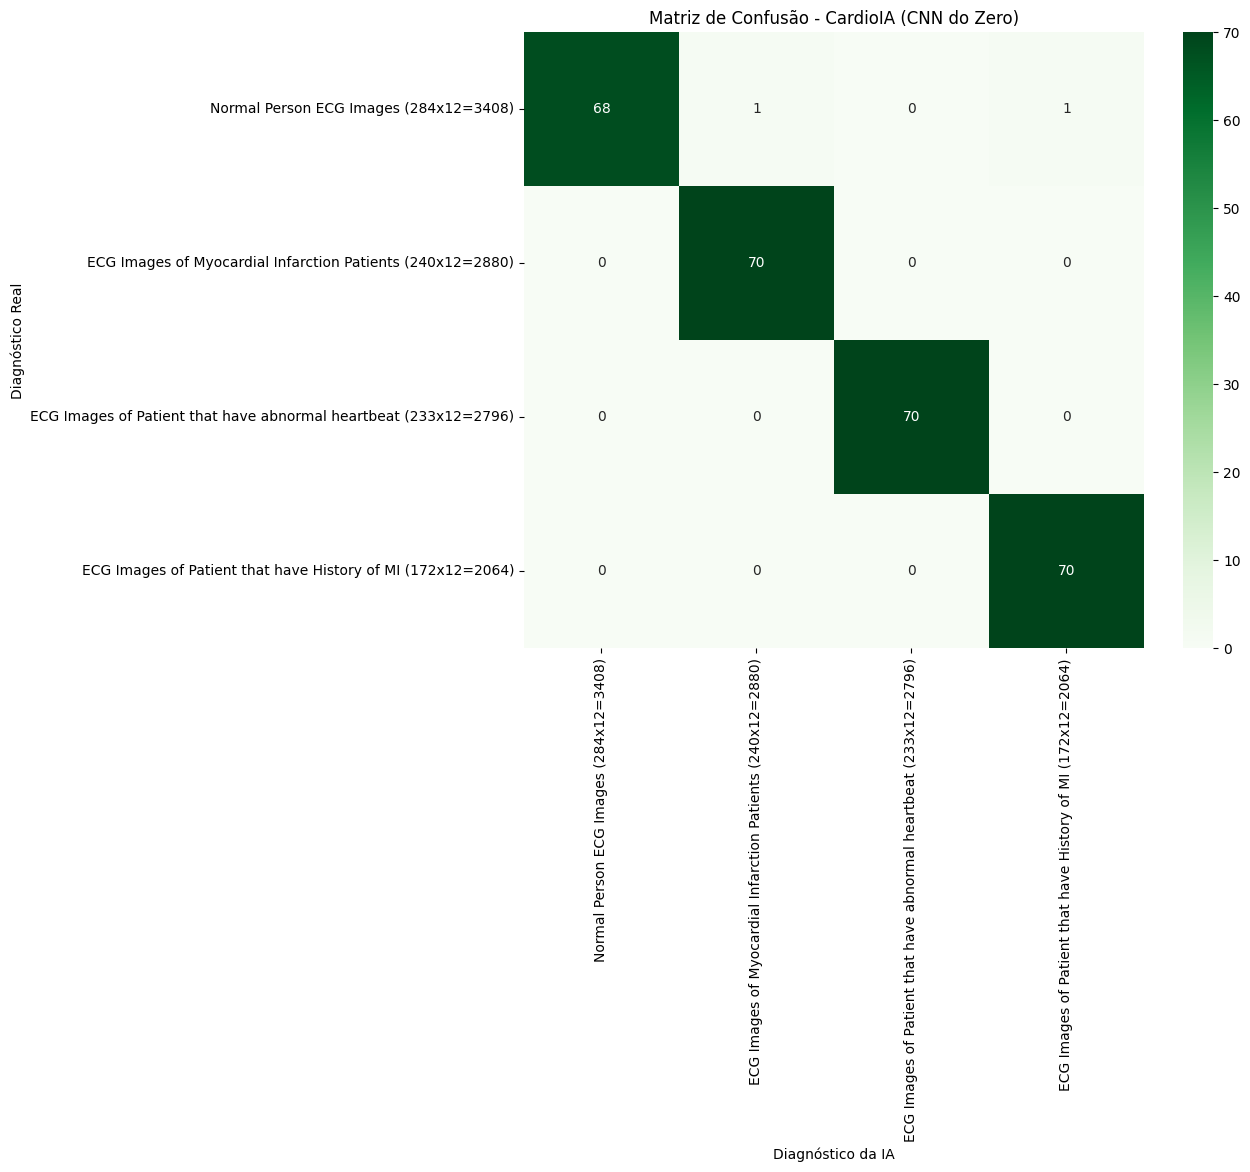

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Fazendo as previsões com modelo construído
y_pred = modelo_basico.predict(X_test)

# Convertendo de volta de probabilidades para o número da classe (0, 1, 2, 3)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("--- RELATÓRIO DE CLASSIFICAÇÃO FINAL ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=categorias))

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=categorias, yticklabels=categorias)
plt.ylabel('Diagnóstico Real')
plt.xlabel('Diagnóstico da IA')
plt.title('Matriz de Confusão - CardioIA (CNN do Zero)')
plt.show()

In [ ]:
from tensorflow.keras.applications import VGG16

# Importando a base da VGG16 sem a camada final de classificação (include_top=False)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelando a base
base_model.trainable = False

# Criando modelo final unindo a VGG16 com a camada de classificação
modelo_transfer = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

modelo_transfer.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Iniciando o treinamento com Transfer Learning...")
history_transfer = modelo_transfer.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_val, y_val),
    class_weight=pesos_das_classes
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Iniciando o treinamento com Transfer Learning...
Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.2637 - loss: 2.2107 - val_accuracy: 0.2782 - val_loss: 1.3477
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.3691 - loss: 1.3288 - val_accuracy: 0.4361 - val_loss: 1.2956
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.4087 - loss: 1.2808 - val_accuracy: 0.4962 - val_loss: 1.2726
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.4444 - loss: 1.2599 - val_accuracy: 0.4812 - val_loss: 1.2475
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.4652 - loss: 1.2300 - val_accuracy: 0.6015 - val_loss: 1.1866
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.4783 - loss: 1.1934 - val_accuracy: 0.6241 - val_loss: 1.1419
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 224ms/step - accuracy: 0.4670 - loss: 1.1999 - val_accuracy: 0.7368 - val_loss: 1.1402
Epoch 

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step
--- RELATÓRIO DE CLASSIFICAÇÃO ---
                                                                  precision    recall  f1-score   support

                          Normal Person ECG Images (284x12=3408)       0.78      0.89      0.83        70
      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.96      0.64      0.77        70
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       0.77      0.96      0.85        70
     ECG Images of Patient that have History of MI (172x12=2064)       0.75      0.71      0.73        70

                                                        accuracy                           0.80       280
                                                       macro avg       0.81      0.80      0.80       280
                                                    weighted avg       0.81      0.80      0.80       280



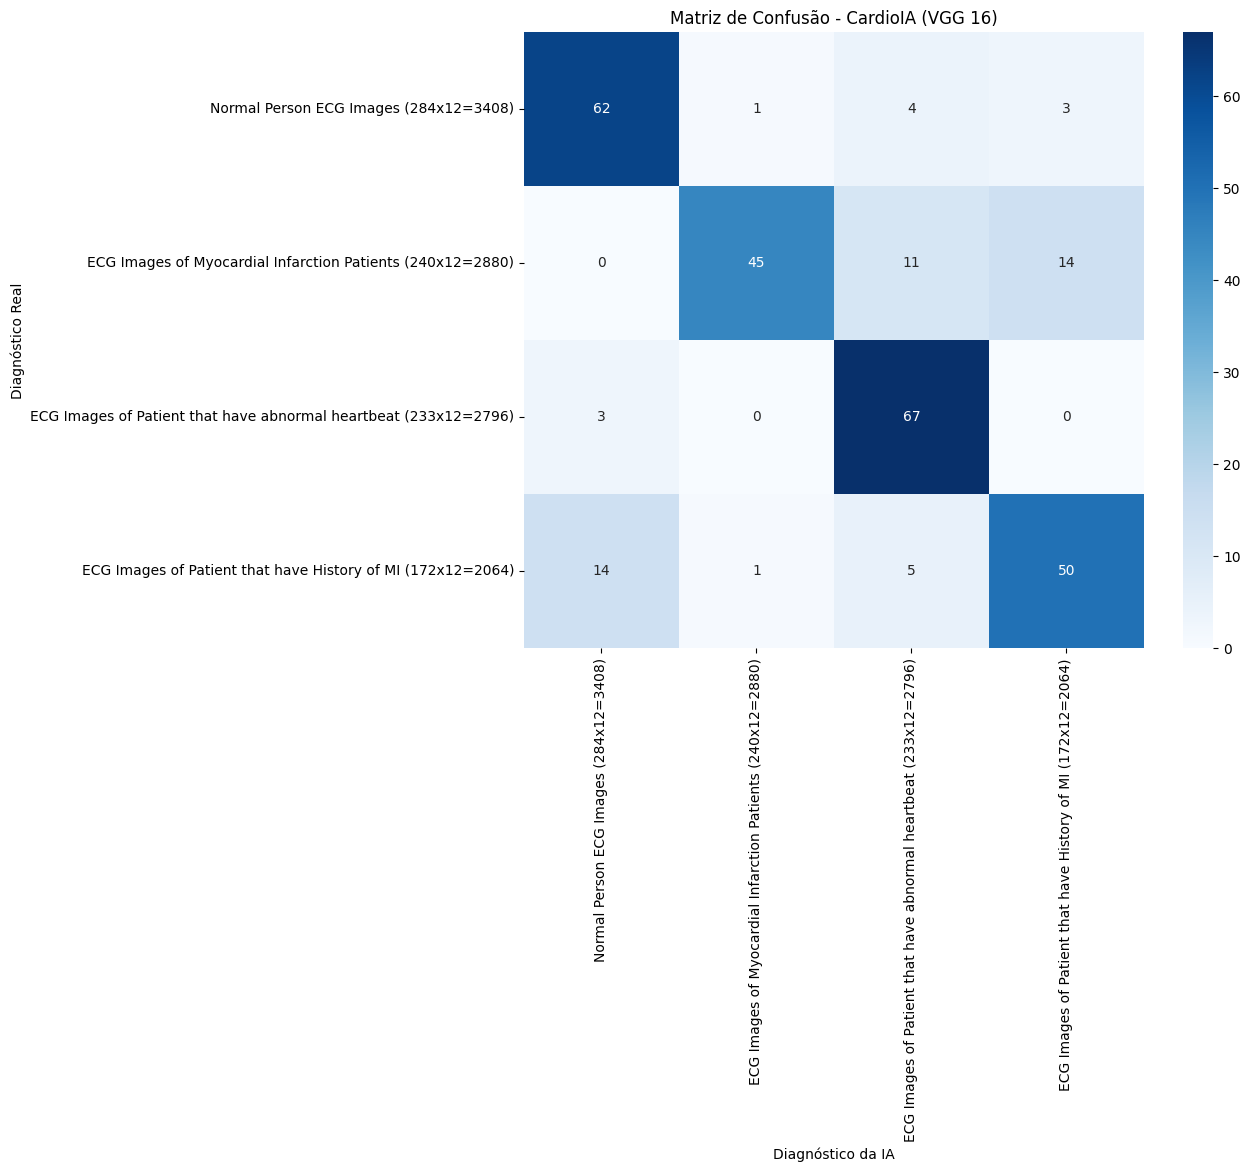

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Fazendo as previsões com os dados de Teste
y_pred = modelo_transfer.predict(X_test)

# Convertendo de volta de probabilidades para o número da classe (0, 1, 2, 3)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=categorias))

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categorias, yticklabels=categorias)
plt.ylabel('Diagnóstico Real')
plt.xlabel('Diagnóstico da IA')
plt.title('Matriz de Confusão - CardioIA (VGG 16)')
plt.show()

# A Interface de Apresentação

Assistente Cardiológico Virtual - CardioIA
Por favor, faça o upload de uma imagem de ECG para análise:


Saving test (75).jpg to test (75).jpg

Analisando o exame: test (75).jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/tmp/ipykernel_11160/2525474142.py:64: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11160/2525474142.py:64: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11160/2525474142.py:64: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fig

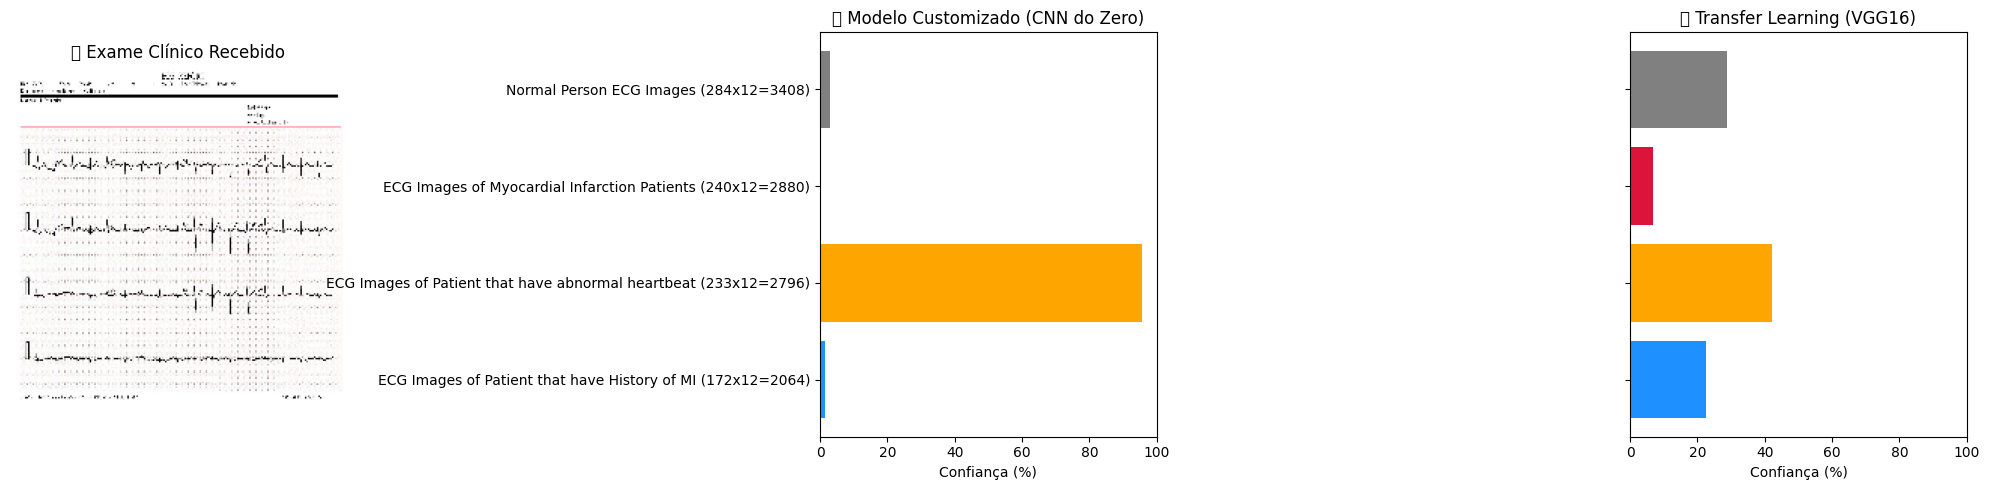


📋 LAUDO TÉCNICO COMPARATIVO - CARDIOIA
----------------------------------------------------------------------
🟢 [CNN DO ZERO] Diagnóstico: ECG Images of Patient that have abnormal heartbeat (233x12=2796) | Confiança: 95.73%
🔴 [VGG16]      Diagnóstico: ECG Images of Patient that have abnormal heartbeat (233x12=2796) | Confiança: 42.13%



In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("Assistente Cardiológico Virtual - CardioIA")
print("Por favor, faça o upload de uma imagem de ECG para análise:")

# Cria o botão de upload no Colab
uploaded = files.upload()

for fn in uploaded.keys():
    print(f"\nAnalisando o exame: {fn}...")

    # Lendo a imagem enviada
    img_array = np.frombuffer(uploaded[fn], np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

    # Aplicando o pré-processamento
    img_resized = cv2.resize(img, (224, 224))
    img_normalized = img_resized.astype('float32') / 255.0
    img_expanded = np.expand_dims(img_normalized, axis=0)

    # Fazendo a Previsão com o modelo construído
    prob_basico = modelo_basico.predict(img_expanded)[0]
    classe_basico = np.argmax(prob_basico)
    diag_basico = categorias[classe_basico]
    conf_basico = prob_basico[classe_basico] * 100

    # 🧠 2. Previsão com o Modelo de Transfer Learning (VGG16)
    prob_transfer = modelo_transfer.predict(img_expanded)[0]
    classe_transfer = np.argmax(prob_transfer)
    diag_transfer = categorias[classe_transfer]
    conf_transfer = prob_transfer[classe_transfer] * 100

    # 📊 Interface Visual: Configurando 3 colunas lado a lado
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
    y_pos = np.arange(len(categorias))
    cores_barras = ['gray', 'crimson', 'orange', 'dodgerblue']

    # Coluna 1: O Exame Clínico
    ax1.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    ax1.set_title("📄 Exame Clínico Recebido")
    ax1.axis('off')

    # Coluna 2: Análise da CNN do Zero (Seu Modelo Campeão)
    ax2.barh(y_pos, prob_basico * 100, align='center', color=cores_barras)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(categorias)
    ax2.invert_yaxis()  # Ordem de cima para baixo
    ax2.set_xlabel('Confiança (%)')
    ax2.set_title('🟢 Modelo Customizado (CNN do Zero)')
    ax2.set_xlim(0, 100)

    # Coluna 3: Análise do Transfer Learning (VGG16)
    ax3.barh(y_pos, prob_transfer * 100, align='center', color=cores_barras)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([]) # Oculta os nomes para não repetir e poluir a tela
    ax3.invert_yaxis()
    ax3.set_xlabel('Confiança (%)')
    ax3.set_title('🔴 Transfer Learning (VGG16)')
    ax3.set_xlim(0, 100)

    plt.tight_layout()
    plt.show()

    # 🧾 Laudo Técnico Comparativo
    print("\n" + "="*70)
    print("📋 LAUDO TÉCNICO COMPARATIVO - CARDIOIA")
    print("-"*70)
    print(f"🟢 [CNN DO ZERO] Diagnóstico: {diag_basico:<50} | Confiança: {conf_basico:.2f}%")
    print(f"🔴 [VGG16]      Diagnóstico: {diag_transfer:<50} | Confiança: {conf_transfer:.2f}%")
    print("="*70 + "\n")